# 03 — Deep Learning Lightweight, Ensemble và Diễn giải 

Notebook này thực hiện phần 03:

1. Tạo sequence data với `lookback=168`.
2. Huấn luyện 5 mô hình deep learning nhẹ: **LSTM, GRU, TSMixer-lite, PatchTST-lite, iTransformer-mini**.
3. Chạy thêm XGBoost/CatBoost compact để ensemble.
4. Ensemble boosting + deep model bằng weight search trên validation.
5. Phân tích lỗi theo giờ/tháng và permutation importance cho deep model tốt nhất.

Tất cả output của notebook này được lưu riêng vào:

- `outputs_03/`
- `figures_03/`
- `models_03/`

In [1]:
# =========================
# 0. Imports, paths, config
# =========================

from pathlib import Path
import os
import time
import copy
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

# -------------------------
# Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

# -------------------------
# Paths
# -------------------------
BASE_DIR = Path(".")
INPUT_DIR = BASE_DIR / "outputs"      # output từ notebook 01
OUT_DIR = BASE_DIR / "outputs_03"
FIG_DIR = BASE_DIR / "figures_03"
MODEL_DIR = BASE_DIR / "models_03"

for d in [OUT_DIR, FIG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Main config
# -------------------------
TARGETS_TO_RUN = ["target_1h", "target_24h"]

# Chạy đủ 5 model theo kế hoạch 03
MODELS_TO_RUN = ["LSTM", "GRU", "TSMixer", "PatchTST", "iTransformer"]

LOOKBACK = 168              # 7 ngày hourly history
BATCH_SIZE = 128
MAX_EPOCHS = 30            
PATIENCE = 6
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

DAYLIGHT_THRESHOLD = 1.0
RUN_BOOSTING_FOR_ENSEMBLE = True
RUN_PERMUTATION_IMPORTANCE = True
PERMUTATION_SAMPLE_SIZE = 800

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Load dữ liệu từ Ngày 1

In [2]:
# =========================
# 1. Load processed data
# =========================

processed_path = INPUT_DIR / "processed_morocco_hourly_features.csv"
feature_path = INPUT_DIR / "feature_columns.csv"

if not processed_path.exists():
    raise FileNotFoundError(f"Không tìm thấy {processed_path}. Hãy chạy notebook Ngày 1 trước.")

if not feature_path.exists():
    raise FileNotFoundError(f"Không tìm thấy {feature_path}. Hãy chạy notebook Ngày 1 trước.")

feat_df = pd.read_csv(processed_path, index_col=0, parse_dates=True).sort_index()
feat_df = feat_df.replace([np.inf, -np.inf], np.nan)

feature_cols_raw = pd.read_csv(feature_path).iloc[:, 0].astype(str).tolist()

print("Data shape:", feat_df.shape)
print("Date range:", feat_df.index.min(), "→", feat_df.index.max())
print("Raw feature columns:", len(feature_cols_raw))

required_cols = ["Solar_Energy_kJ_m2", "target_1h", "target_24h"]
missing_required = [c for c in required_cols if c not in feat_df.columns]
if missing_required:
    raise ValueError(f"Thiếu các cột bắt buộc: {missing_required}")

display(feat_df.head(3))

Data shape: (25944, 77)
Date range: 2016-01-15 00:00:00 → 2018-12-30 23:00:00
Raw feature columns: 67


,YEAR,MO,DY,HR,Pressure,Wind_Speed,Wind_Direction,Humidity,Solar_Radiation_Wh_m2,Temperature,...,pvlib_solar_elevation_deg,pvlib_solar_zenith_deg,pvlib_clear_sky_ghi_Wh_m2,pvlib_clear_sky_index_current,sim_cell_temperature_C,sim_pv_dc_kWh_per_kWp,sim_pv_ac_kWh_per_kWp,sim_pv_ac_lag_1h,sim_pv_ac_lag_24h,sim_pv_ac_lag_168h
datetime,,,,,,,,,,,,,,,,,,,,,
2016-01-15 00:00:00,2016,1,15,0,87.59,2.58,312.0,35.68,0.0,6.87,...,-77.778787,167.778787,0.0,0.0,6.87,0.0,0.0,0.0,0.0,0.0
2016-01-15 01:00:00,2016,1,15,1,87.55,2.59,318.1,36.85,0.0,6.45,...,-77.001686,167.001686,0.0,0.0,6.45,0.0,0.0,0.0,0.0,0.0
2016-01-15 02:00:00,2016,1,15,2,87.51,2.62,321.0,38.12,0.0,6.01,...,-66.650803,156.650803,0.0,0.0,6.01,0.0,0.0,0.0,0.0,0.0


## 2. Chọn feature cho deep learning

Notebook dùng bộ feature gọn hơn so với toàn bộ tabular features để giảm rủi ro overfitting và giảm thời gian train. Các cột không tồn tại sẽ tự động bỏ qua.

In [3]:
# =========================
# 2. Sequence feature selection
# =========================

forbidden_cols = {
    "YEAR", "MO", "DY", "HR",
    "target_1h", "target_24h",
    "pvlib_available",
}

candidate_features = [
    # Current observed solar/weather state
    "Solar_Energy_kJ_m2",
    "Solar_Radiation_Wh_m2",
    "Temperature",
    "Humidity",
    "Pressure",
    "Wind_Speed",
    "Wind_Direction",

    # Cyclic time
    "hour_sin", "hour_cos",
    "doy_sin", "doy_cos",
    "month_sin", "month_cos",

    # Geometry / physical features
    "solar_elevation_approx_deg",
    "sun_up_by_geometry",
    "is_daylight_geometry",
    "clear_sky_ghi_proxy_Wh_m2",
    "clear_sky_index_current",
    "pvlib_solar_elevation_deg",
    "pvlib_solar_zenith_deg",
    "pvlib_clear_sky_ghi_Wh_m2",
    "pvlib_clear_sky_index_current",
    "sim_cell_temperature_C",
    "sim_pv_dc_kWh_per_kWp",
    "sim_pv_ac_kWh_per_kWp",

    # Target lags
    "Solar_Energy_kJ_m2_lag_1h",
    "Solar_Energy_kJ_m2_lag_2h",
    "Solar_Energy_kJ_m2_lag_3h",
    "Solar_Energy_kJ_m2_lag_6h",
    "Solar_Energy_kJ_m2_lag_12h",
    "Solar_Energy_kJ_m2_lag_24h",
    "Solar_Energy_kJ_m2_lag_48h",
    "Solar_Energy_kJ_m2_lag_72h",
    "Solar_Energy_kJ_m2_lag_168h",

    # Rolling target statistics
    "Solar_Energy_kJ_m2_roll_mean_3h",
    "Solar_Energy_kJ_m2_roll_mean_6h",
    "Solar_Energy_kJ_m2_roll_mean_24h",
    "Solar_Energy_kJ_m2_roll_mean_72h",
    "Solar_Energy_kJ_m2_roll_mean_168h",
    "Solar_Energy_kJ_m2_roll_std_3h",
    "Solar_Energy_kJ_m2_roll_std_6h",
    "Solar_Energy_kJ_m2_roll_std_24h",
    "Solar_Energy_kJ_m2_roll_std_72h",
    "Solar_Energy_kJ_m2_roll_std_168h",
    "Solar_Energy_kJ_m2_roll_max_24h",
    "Solar_Energy_kJ_m2_roll_min_24h",

    # Simulated PV lags
    "sim_pv_ac_lag_1h",
    "sim_pv_ac_lag_24h",
    "sim_pv_ac_lag_168h",
]

seq_features = [
    c for c in candidate_features
    if c in feat_df.columns and c not in forbidden_cols
]

# Bổ sung một số lag/rolling nếu tên cột khác nhưng có trong feature_columns.csv
extra_safe = []
safe_keywords = ["_lag_", "_roll_mean_", "_roll_std_"]
for c in feature_cols_raw:
    if c in feat_df.columns and c not in forbidden_cols and any(k in c for k in safe_keywords):
        extra_safe.append(c)

seq_features = list(dict.fromkeys(seq_features + extra_safe))

# Chỉ giữ numeric, không hằng số
seq_features = [
    c for c in seq_features
    if pd.api.types.is_numeric_dtype(feat_df[c])
    and feat_df[c].nunique(dropna=True) > 1
]

print("Number of sequence features:", len(seq_features))
print(seq_features)

# Kiểm tra nhanh missing ở bộ feature
missing_ratio = feat_df[seq_features].isna().mean().sort_values(ascending=False)
print("Max missing ratio among seq_features:", float(missing_ratio.max()))

Number of sequence features: 60
['Solar_Energy_kJ_m2', 'Solar_Radiation_Wh_m2', 'Temperature', 'Humidity', 'Pressure', 'Wind_Speed', 'Wind_Direction', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'solar_elevation_approx_deg', 'sun_up_by_geometry', 'is_daylight_geometry', 'clear_sky_ghi_proxy_Wh_m2', 'clear_sky_index_current', 'pvlib_solar_elevation_deg', 'pvlib_solar_zenith_deg', 'pvlib_clear_sky_ghi_Wh_m2', 'pvlib_clear_sky_index_current', 'sim_cell_temperature_C', 'sim_pv_dc_kWh_per_kWp', 'sim_pv_ac_kWh_per_kWp', 'Solar_Energy_kJ_m2_lag_1h', 'Solar_Energy_kJ_m2_lag_2h', 'Solar_Energy_kJ_m2_lag_3h', 'Solar_Energy_kJ_m2_lag_6h', 'Solar_Energy_kJ_m2_lag_12h', 'Solar_Energy_kJ_m2_lag_24h', 'Solar_Energy_kJ_m2_lag_48h', 'Solar_Energy_kJ_m2_lag_72h', 'Solar_Energy_kJ_m2_lag_168h', 'Solar_Energy_kJ_m2_roll_mean_3h', 'Solar_Energy_kJ_m2_roll_mean_6h', 'Solar_Energy_kJ_m2_roll_mean_24h', 'Solar_Energy_kJ_m2_roll_mean_72h', 'Solar_Energy_kJ_m2_roll_mean_168h', 'Solar

## 3. Metric functions

Hàm metric được viết theo hướng robust: nếu độ dài `y_true`, `y_pred`, `persistence_pred` lệch nhau thì tự align theo phần cuối chuỗi để tránh lỗi boolean mask.

In [4]:
# =========================
# 3. Metrics
# =========================

def _to_1d(a):
    return np.asarray(a).reshape(-1)

def _align_tail(*arrays):
    arrays = [_to_1d(a) for a in arrays if a is not None]
    n = min(len(a) for a in arrays)
    return [a[-n:] for a in arrays]

def rmse_score(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def nrmse_score(y_true, y_pred):
    denom = float(np.max(y_true) - np.min(y_true))
    return rmse_score(y_true, y_pred) / denom if denom > 0 else np.nan

def evaluate_predictions(y_true, y_pred, persistence_pred=None, daylight_threshold=DAYLIGHT_THRESHOLD):
    y_true, y_pred = _align_tail(y_true, y_pred)

    out = {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse_score(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
        "MaxError": float(max_error(y_true, y_pred)),
        "NRMSE": nrmse_score(y_true, y_pred),
    }

    daylight_mask = y_true > daylight_threshold
    if int(daylight_mask.sum()) > 5:
        yt = y_true[daylight_mask]
        yp = y_pred[daylight_mask]
        out.update({
            "daylight_MAE": float(mean_absolute_error(yt, yp)),
            "daylight_RMSE": rmse_score(yt, yp),
            "daylight_R2": float(r2_score(yt, yp)),
            "daylight_MaxError": float(max_error(yt, yp)),
            "daylight_NRMSE": nrmse_score(yt, yp),
        })
    else:
        for k in ["MAE", "RMSE", "R2", "MaxError", "NRMSE"]:
            out[f"daylight_{k}"] = np.nan

    if persistence_pred is not None:
        y_s, pred_s, p_s = _align_tail(y_true, y_pred, persistence_pred)
        mask = y_s > daylight_threshold
        if int(mask.sum()) > 5:
            p_rmse = rmse_score(y_s[mask], p_s[mask])
            m_rmse = rmse_score(y_s[mask], pred_s[mask])
            out["skill_vs_persistence_daylight"] = float(1 - m_rmse / p_rmse) if p_rmse > 0 else np.nan
        else:
            out["skill_vs_persistence_daylight"] = np.nan
    else:
        out["skill_vs_persistence_daylight"] = np.nan

    return out

def print_metric_short(prefix, metrics):
    print(f"{prefix} daylight RMSE={metrics.get('daylight_RMSE', np.nan):.4f}, "
          f"R2={metrics.get('daylight_R2', np.nan):.4f}, "
          f"skill={metrics.get('skill_vs_persistence_daylight', np.nan):.4f}")

## 4. Tạo sequence dataset

Mỗi sample dùng 168 giờ lịch sử để dự báo `target_1h` hoặc `target_24h`. Split vẫn theo mốc thời gian của feature row để đồng bộ với notebook Ngày 2.

In [5]:
# =========================
# 4. Sequence dataset
# =========================

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_sequence_data(df, features, target_col, lookback=168, persistence_col="Solar_Energy_kJ_m2"):
    cols = list(dict.fromkeys(features + [target_col, persistence_col]))
    sub = df[cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    sub = sub.sort_index()

    X_values = sub[features].astype(np.float32).values
    y_values = sub[target_col].astype(np.float32).values
    p_values = sub[persistence_col].astype(np.float32).values
    times = sub.index

    X_seq, y_seq, p_seq, t_seq = [], [], [], []
    for i in range(lookback - 1, len(sub)):
        X_seq.append(X_values[i - lookback + 1 : i + 1])
        y_seq.append(y_values[i])
        p_seq.append(p_values[i])
        t_seq.append(times[i])

    X_seq = np.asarray(X_seq, dtype=np.float32)
    y_seq = np.asarray(y_seq, dtype=np.float32)
    p_seq = np.asarray(p_seq, dtype=np.float32)
    t_seq = pd.DatetimeIndex(t_seq)

    # Safety checks
    assert X_seq.ndim == 3, f"X_seq must be 3D, got {X_seq.shape}"
    assert X_seq.shape[-1] == len(features), f"Feature mismatch: X has {X_seq.shape[-1]}, feature list has {len(features)}"
    assert len(X_seq) == len(y_seq) == len(p_seq) == len(t_seq), "Sequence arrays length mismatch"

    return X_seq, y_seq, t_seq, p_seq


def split_by_time(X_seq, y_seq, t_seq, p_seq):
    t_seq = pd.DatetimeIndex(t_seq)
    train_mask = t_seq <= pd.Timestamp("2017-12-31 23:00:00")
    val_mask = (t_seq >= pd.Timestamp("2018-01-01 00:00:00")) & (t_seq <= pd.Timestamp("2018-06-30 23:00:00"))
    test_mask = (t_seq >= pd.Timestamp("2018-07-01 00:00:00")) & (t_seq <= pd.Timestamp("2018-12-31 23:00:00"))

    data = {
        "train": (X_seq[train_mask], y_seq[train_mask], t_seq[train_mask], p_seq[train_mask]),
        "val": (X_seq[val_mask], y_seq[val_mask], t_seq[val_mask], p_seq[val_mask]),
        "test": (X_seq[test_mask], y_seq[test_mask], t_seq[test_mask], p_seq[test_mask]),
    }

    for split_name, (X, y, t, p) in data.items():
        if len(X) == 0:
            raise ValueError(f"Split {split_name} is empty. Check date range or lookback.")
        assert len(X) == len(y) == len(t) == len(p), f"{split_name} length mismatch"
    return data


def scale_sequence_data(data):
    X_train, y_train, t_train, p_train = data["train"]
    X_val, y_val, t_val, p_val = data["val"]
    X_test, y_test, t_test, p_test = data["test"]

    n_features = X_train.shape[-1]

    x_scaler = StandardScaler()
    x_scaler.fit(X_train.reshape(-1, n_features))

    def scale_X(X):
        return x_scaler.transform(X.reshape(-1, n_features)).reshape(X.shape).astype(np.float32)

    y_scaler = StandardScaler()
    y_scaler.fit(y_train.reshape(-1, 1))

    scaled = {
        "train": (scale_X(X_train), y_scaler.transform(y_train.reshape(-1, 1)).reshape(-1).astype(np.float32), y_train, t_train, p_train),
        "val": (scale_X(X_val), y_scaler.transform(y_val.reshape(-1, 1)).reshape(-1).astype(np.float32), y_val, t_val, p_val),
        "test": (scale_X(X_test), y_scaler.transform(y_test.reshape(-1, 1)).reshape(-1).astype(np.float32), y_test, t_test, p_test),
    }

    for split_name, item in scaled.items():
        X_s, y_s, y_orig, t, p = item
        assert len(X_s) == len(y_s) == len(y_orig) == len(t) == len(p), f"{split_name} scaled length mismatch"
        assert X_s.shape[-1] == n_features, f"{split_name} feature dimension mismatch"

    return scaled, x_scaler, y_scaler

## 5. Định nghĩa mô hình deep learning

In [6]:
# =========================
# 5. Model definitions
# =========================

class RecurrentRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=96, num_layers=2, dropout=0.15, rnn_type="LSTM"):
        super().__init__()
        rnn_cls = nn.LSTM if rnn_type == "LSTM" else nn.GRU
        self.rnn = rnn_cls(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])


class TSMixerBlock(nn.Module):
    def __init__(self, seq_len, n_features, hidden_dim=128, dropout=0.15):
        super().__init__()
        self.time_norm = nn.LayerNorm(n_features)
        self.time_mlp = nn.Sequential(
            nn.Linear(seq_len, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, seq_len),
            nn.Dropout(dropout),
        )
        self.feature_norm = nn.LayerNorm(n_features)
        self.feature_mlp = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_features),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: [B, L, C]
        y = self.time_norm(x).transpose(1, 2)     # [B, C, L]
        y = self.time_mlp(y).transpose(1, 2)      # [B, L, C]
        x = x + y

        y = self.feature_norm(x)
        y = self.feature_mlp(y)
        x = x + y
        return x


class TSMixerRegressor(nn.Module):
    def __init__(self, seq_len, n_features, hidden_dim=128, num_blocks=3, dropout=0.15):
        super().__init__()
        self.blocks = nn.ModuleList([
            TSMixerBlock(seq_len, n_features, hidden_dim=hidden_dim, dropout=dropout)
            for _ in range(num_blocks)
        ])
        self.head = nn.Sequential(
            nn.LayerNorm(n_features),
            nn.Flatten(),
            nn.Linear(seq_len * n_features, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return self.head(x)


class PatchTSTLiteRegressor(nn.Module):
    def __init__(self, seq_len, n_features, patch_len=24, stride=12, d_model=128, nhead=4, num_layers=2, dropout=0.15):
        super().__init__()
        self.seq_len = seq_len
        self.n_features = n_features
        self.patch_len = patch_len
        self.stride = stride
        self.num_patches = 1 + (seq_len - patch_len) // stride

        self.patch_proj = nn.Linear(n_features * patch_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x: [B, L, C]
        patches = x.unfold(dimension=1, size=self.patch_len, step=self.stride)  # [B, N, C, P]
        patches = patches.contiguous().reshape(x.size(0), self.num_patches, self.n_features * self.patch_len)
        z = self.patch_proj(patches)
        z = self.encoder(z)
        z = z.mean(dim=1)
        return self.head(z)


class iTransformerMiniRegressor(nn.Module):
    def __init__(self, seq_len, n_features, d_model=128, nhead=4, num_layers=2, dropout=0.15):
        super().__init__()
        self.seq_len = seq_len
        self.n_features = n_features
        self.variable_proj = nn.Linear(seq_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x: [B, L, C] -> variables as tokens: [B, C, L]
        z = x.transpose(1, 2)
        z = self.variable_proj(z)       # [B, C, D]
        z = self.encoder(z)
        z = z.mean(dim=1)               # aggregate variable tokens
        return self.head(z)


def build_model(model_name, seq_len, n_features):
    if model_name == "LSTM":
        model = RecurrentRegressor(n_features, rnn_type="LSTM")
    elif model_name == "GRU":
        model = RecurrentRegressor(n_features, rnn_type="GRU")
    elif model_name == "TSMixer":
        model = TSMixerRegressor(seq_len, n_features)
    elif model_name == "PatchTST":
        model = PatchTSTLiteRegressor(seq_len, n_features)
    elif model_name == "iTransformer":
        model = iTransformerMiniRegressor(seq_len, n_features)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model.to(DEVICE)

## 6. Huấn luyện và dự đoán

In [7]:
# =========================
# 6. Training helpers
# =========================

def train_one_model(model, train_loader, val_loader, max_epochs=30, lr=1e-3, weight_decay=1e-5, patience=6):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.HuberLoss(delta=1.0)

    best_state = None
    best_val = np.inf
    wait = 0
    history = []
    start = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(float(loss.detach().cpu()))

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE, non_blocking=True)
                yb = yb.to(DEVICE, non_blocking=True)
                pred = model(xb)
                val_loss = criterion(pred, yb)
                val_losses.append(float(val_loss.detach().cpu()))

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if epoch == 1 or epoch % 5 == 0:
            print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}. Best val_loss={best_val:.6f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    elapsed = time.time() - start
    return model, pd.DataFrame(history), elapsed


def predict_model(model, X, y_scaler, batch_size=512):
    model.eval()
    dummy_y = np.zeros(len(X), dtype=np.float32)
    loader = DataLoader(SequenceDataset(X, dummy_y), batch_size=batch_size, shuffle=False)

    preds_scaled = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            pred = model(xb).detach().cpu().numpy().reshape(-1)
            preds_scaled.append(pred)

    preds_scaled = np.concatenate(preds_scaled)
    preds = y_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(-1)
    return np.clip(preds, 0, None)

## 7. Train deep learning models cho `target_1h` và `target_24h`

In [8]:
# =========================
# 7. Train DL models
# =========================

dl_results = []
history_records = []
prediction_store = {}
scaler_store = {}
sequence_store = {}
model_checkpoint_paths = {}

for target_col in TARGETS_TO_RUN:
    print("\n" + "=" * 90)
    print(f"TARGET: {target_col}")
    print("=" * 90)

    X_seq, y_seq, times_seq, persistence_seq = make_sequence_data(
        feat_df, seq_features, target_col, lookback=LOOKBACK
    )
    data = split_by_time(X_seq, y_seq, times_seq, persistence_seq)
    scaled_data, x_scaler, y_scaler = scale_sequence_data(data)

    scaler_store[target_col] = {"x_scaler": x_scaler, "y_scaler": y_scaler}
    sequence_store[target_col] = {"scaled_data": scaled_data, "seq_features": seq_features}

    X_train, y_train_scaled, y_train_orig, t_train, p_train = scaled_data["train"]
    X_val, y_val_scaled, y_val_orig, t_val, p_val = scaled_data["val"]
    X_test, y_test_scaled, y_test_orig, t_test, p_test = scaled_data["test"]

    actual_n_features = X_train.shape[-1]
    print("Train sequence:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
    print("Feature list length:", len(seq_features), "| Actual n_features:", actual_n_features)

    train_loader = DataLoader(
        SequenceDataset(X_train, y_train_scaled),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        SequenceDataset(X_val, y_val_scaled),
        batch_size=BATCH_SIZE * 2,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    for model_name in MODELS_TO_RUN:
        print("\n" + "-" * 70)
        print(f"Training {model_name} for {target_col}")
        print("-" * 70)

        try:
            model = build_model(model_name, seq_len=LOOKBACK, n_features=actual_n_features)
            model, hist_df, elapsed = train_one_model(
                model, train_loader, val_loader,
                MAX_EPOCHS, LEARNING_RATE, WEIGHT_DECAY, PATIENCE
            )

            val_pred = predict_model(model, X_val, y_scaler)
            test_pred = predict_model(model, X_test, y_scaler)

            val_metrics = evaluate_predictions(y_val_orig, val_pred, persistence_pred=p_val)
            test_metrics = evaluate_predictions(y_test_orig, test_pred, persistence_pred=p_test)

            row = {
                "target": target_col,
                "model": model_name,
                "model_type": "deep_learning",
                "lookback": LOOKBACK,
                "n_features": actual_n_features,
                "train_seconds": elapsed,
                "status": "ok",
                **{f"val_{k}": v for k, v in val_metrics.items()},
                **{f"test_{k}": v for k, v in test_metrics.items()},
            }
            dl_results.append(row)

            hist_df["target"] = target_col
            hist_df["model"] = model_name
            history_records.append(hist_df)

            prediction_store[(target_col, model_name)] = {
                "val_pred": val_pred,
                "test_pred": test_pred,
                "val_true": _align_tail(y_val_orig, val_pred)[0],
                "test_true": _align_tail(y_test_orig, test_pred)[0],
                "val_time": pd.DatetimeIndex(t_val)[-len(val_pred):],
                "test_time": pd.DatetimeIndex(t_test)[-len(test_pred):],
                "val_persistence": _align_tail(p_val, val_pred)[0],
                "test_persistence": _align_tail(p_test, test_pred)[0],
            }

            checkpoint_path = MODEL_DIR / f"03_{target_col}_{model_name}.pt"
            torch.save({
                "model_name": model_name,
                "target": target_col,
                "seq_features": seq_features,
                "n_features": actual_n_features,
                "lookback": LOOKBACK,
                "state_dict": model.state_dict(),
            }, checkpoint_path)
            model_checkpoint_paths[(target_col, model_name)] = checkpoint_path

            print_metric_short("Val ", val_metrics)
            print_metric_short("Test", test_metrics)

            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            print(f"ERROR while training {model_name} for {target_col}: {e}")
            dl_results.append({
                "target": target_col,
                "model": model_name,
                "model_type": "deep_learning",
                "lookback": LOOKBACK,
                "n_features": actual_n_features,
                "train_seconds": np.nan,
                "status": f"failed: {e}",
            })

dl_results_df = pd.DataFrame(dl_results)
ok_mask = dl_results_df["status"].eq("ok") if "status" in dl_results_df.columns else pd.Series([True] * len(dl_results_df))
dl_results_ok = dl_results_df[ok_mask].copy()

if not dl_results_ok.empty:
    dl_results_df = dl_results_df.sort_values(["target", "val_daylight_RMSE"], na_position="last")
else:
    dl_results_df = dl_results_df.sort_values(["target", "model"])

history_df = pd.concat(history_records, ignore_index=True) if history_records else pd.DataFrame()

dl_results_df.to_csv(OUT_DIR / "03_results_deep_learning.csv", index=False)
history_df.to_csv(OUT_DIR / "03_training_history.csv", index=False)

display_cols = [
    "target", "model", "status", "lookback", "n_features", "train_seconds",
    "val_daylight_RMSE", "val_daylight_R2", "val_skill_vs_persistence_daylight",
    "test_daylight_RMSE", "test_daylight_R2", "test_skill_vs_persistence_daylight",
]
display_cols = [c for c in display_cols if c in dl_results_df.columns]
display(dl_results_df[display_cols])


TARGET: target_1h
Train sequence: (17041, 168, 60) Val: (4344, 168, 60) Test: (4392, 168, 60)
Feature list length: 60 | Actual n_features: 60

----------------------------------------------------------------------
Training LSTM for target_1h
----------------------------------------------------------------------
Epoch 001 | train_loss=0.027197 | val_loss=0.006804
Epoch 005 | train_loss=0.007215 | val_loss=0.005842
Epoch 010 | train_loss=0.006186 | val_loss=0.005504
Epoch 015 | train_loss=0.006075 | val_loss=0.003213
Early stopping at epoch 15. Best val_loss=0.002681
Val  daylight RMSE=117.8839, R2=0.9899, skill=0.7840
Test daylight RMSE=119.1179, R2=0.9868, skill=0.7645

----------------------------------------------------------------------
Training GRU for target_1h
----------------------------------------------------------------------
Epoch 001 | train_loss=0.031581 | val_loss=0.007305
Epoch 005 | train_loss=0.007012 | val_loss=0.003137
Epoch 010 | train_loss=0.006081 | val_loss=0.00

,target,model,status,lookback,n_features,train_seconds,val_daylight_RMSE,val_daylight_R2,val_skill_vs_persistence_daylight,test_daylight_RMSE,test_daylight_R2,test_skill_vs_persistence_daylight
0,target_1h,LSTM,ok,168,60,23.255006,117.883902,0.989854,0.783970,119.117896,0.986778,0.764539
1,target_1h,GRU,ok,168,60,23.052207,121.305347,0.989257,0.777700,120.460242,0.986478,0.761886
2,target_1h,TSMixer,ok,168,60,29.348746,140.937431,0.985498,0.741723,151.768082,0.978536,0.699999
4,target_1h,iTransformer,ok,168,60,20.891575,197.853906,0.971420,0.637419,209.652819,0.959041,0.585578
3,target_1h,PatchTST,ok,168,60,59.841388,227.849183,0.962097,0.582451,237.282911,0.947534,0.530962
5,target_24h,LSTM,ok,168,60,12.992805,292.839907,0.937609,0.189296,292.119237,0.919940,0.160220
6,target_24h,GRU,ok,168,60,12.162291,300.889826,0.934132,0.167010,307.621711,0.911217,0.115653
8,target_24h,PatchTST,ok,168,60,31.163591,301.382906,0.933915,0.165645,316.929224,0.905763,0.088896
7,target_24h,TSMixer,ok,168,60,21.443512,316.106020,0.927301,0.124885,307.501054,0.911286,0.116000
9,target_24h,iTransformer,ok,168,60,26.495662,322.740632,0.924217,0.106518,322.904265,0.902176,0.071719


## 8. Loss curves

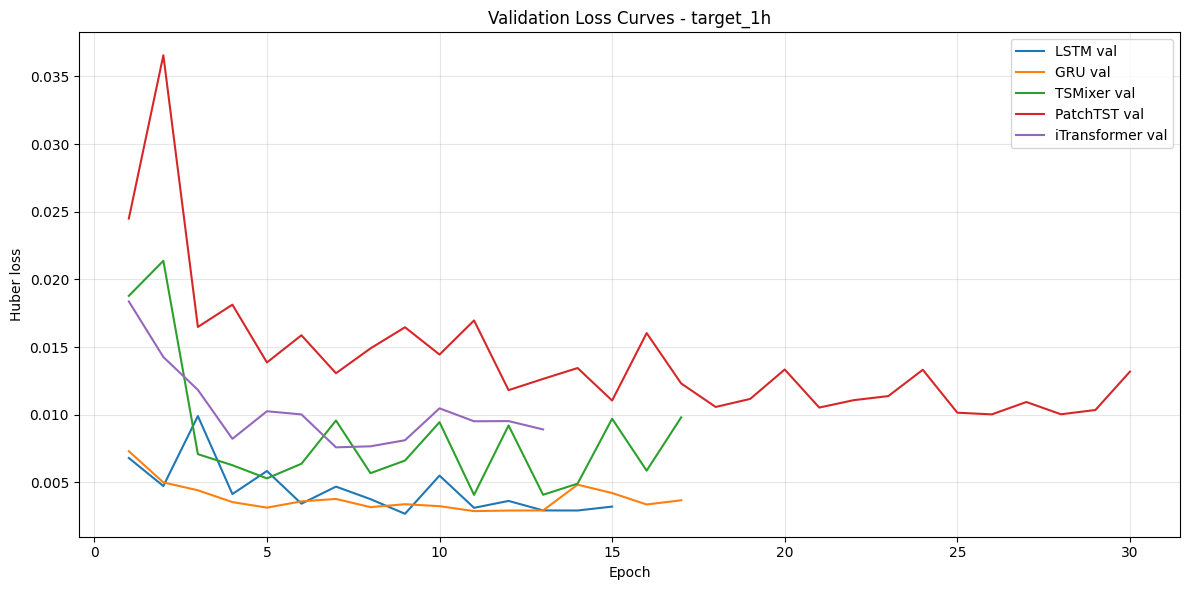

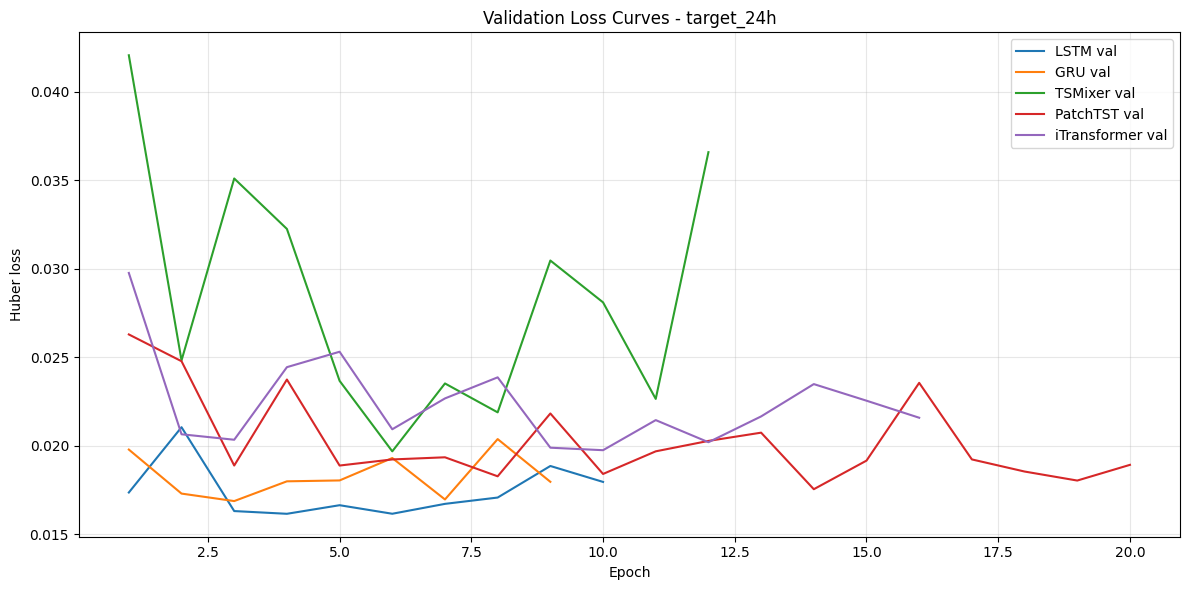

In [9]:
# =========================
# 8. Loss curves
# =========================

if not history_df.empty:
    for target_col in TARGETS_TO_RUN:
        sub_target = history_df[history_df["target"] == target_col]
        if sub_target.empty:
            continue

        plt.figure(figsize=(12, 6))
        for model_name in sub_target["model"].unique():
            sub = sub_target[sub_target["model"] == model_name]
            plt.plot(sub["epoch"], sub["val_loss"], label=f"{model_name} val")
        plt.title(f"Validation Loss Curves - {target_col}")
        plt.xlabel("Epoch")
        plt.ylabel("Huber loss")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"03_loss_curves_{target_col}.png", dpi=160)
        plt.show()
else:
    print("No history available.")

## 9. Train XGBoost/CatBoost compact để ensemble

In [11]:
# =========================
# 9. Boosting predictions for ensemble
# =========================

boosting_results = []
boosting_predictions = {}

# Hàm giữ thứ tự nhưng loại trùng
def unique_keep_order(items):
    return list(dict.fromkeys(items))


# Hàm tạo X sạch cho XGBoost / CatBoost
def make_clean_X(dataframe, cols):
    cols = unique_keep_order([c for c in cols if c in dataframe.columns])

    X = dataframe.loc[:, cols].copy()

    # Loại duplicate columns nếu vẫn còn
    X = X.loc[:, ~X.columns.duplicated()].copy()

    # Ép toàn bộ về numeric
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0)

    return X.astype(np.float32)


# Làm sạch danh sách full features
forbidden_boosting_cols = [
    "target_1h",
    "target_24h",
    "YEAR", "MO", "DY", "HR",
    "pvlib_available",
]

full_features = [
    c for c in feature_cols_raw
    if c in feat_df.columns
    and c not in forbidden_boosting_cols
    and pd.api.types.is_numeric_dtype(feat_df[c])
    and feat_df[c].nunique(dropna=True) > 1
]

# Loại trùng tên feature
full_features = unique_keep_order(full_features)

print("Full tabular feature count for boosting:", len(full_features))
print("Duplicated feature names:", pd.Series(full_features).duplicated().sum())

if RUN_BOOSTING_FOR_ENSEMBLE:
    for target_col in TARGETS_TO_RUN:
        print("\n" + "=" * 90)
        print(f"Boosting for ensemble - {target_col}")

        # Các cột cần lấy từ feat_df
        required_cols = unique_keep_order(
            full_features + [target_col, "Solar_Energy_kJ_m2"]
        )

        tmp = (
            feat_df.loc[:, required_cols]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .copy()
        )

        # Chắc chắn tmp không còn duplicate columns
        tmp = tmp.loc[:, ~tmp.columns.duplicated()].copy()

        train_df = tmp.loc[:"2017-12-31 23:00:00"].copy()
        val_df   = tmp.loc["2018-01-01":"2018-06-30 23:00:00"].copy()
        test_df  = tmp.loc["2018-07-01":"2018-12-31 23:00:00"].copy()

        # Tạo X sạch, không duplicate columns, toàn bộ float32
        X_train = make_clean_X(train_df, full_features)
        X_val   = make_clean_X(val_df, full_features)
        X_test  = make_clean_X(test_df, full_features)

        y_train = pd.to_numeric(train_df[target_col], errors="coerce").astype(np.float32)
        y_val   = pd.to_numeric(val_df[target_col], errors="coerce").astype(np.float32)
        y_test  = pd.to_numeric(test_df[target_col], errors="coerce").astype(np.float32)

        p_val = pd.to_numeric(val_df["Solar_Energy_kJ_m2"], errors="coerce").values.astype(np.float32)
        p_test = pd.to_numeric(test_df["Solar_Energy_kJ_m2"], errors="coerce").values.astype(np.float32)

        print("X_train:", X_train.shape, "| duplicated cols:", X_train.columns.duplicated().sum())
        print("X_val  :", X_val.shape, "| duplicated cols:", X_val.columns.duplicated().sum())
        print("X_test :", X_test.shape, "| duplicated cols:", X_test.columns.duplicated().sum())

        boosting_models = {
            "XGBoost_compact": XGBRegressor(
                n_estimators=700,
                learning_rate=0.04,
                max_depth=5,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="reg:squarederror",
                random_state=SEED,
                n_jobs=-1,
                tree_method="hist",
            ),
            "CatBoost_compact": CatBoostRegressor(
                iterations=700,
                learning_rate=0.04,
                depth=6,
                loss_function="RMSE",
                random_seed=SEED,
                verbose=False,
                allow_writing_files=False,
            ),
        }

        for model_name, model in boosting_models.items():
            print("\n" + "-" * 70)
            print(f"Training {model_name} for {target_col}")
            print("-" * 70)

            start = time.time()

            # XGBoost/CatBoost đều nhận DataFrame sạch không trùng cột
            model.fit(X_train, y_train)

            elapsed = time.time() - start

            val_pred = np.clip(model.predict(X_val), 0, None)
            test_pred = np.clip(model.predict(X_test), 0, None)

            # Align độ dài trước khi evaluate để tránh lỗi mask mismatch
            n_val = min(len(y_val), len(val_pred), len(p_val))
            y_val_eval = y_val.values[-n_val:]
            val_pred_eval = val_pred[-n_val:]
            p_val_eval = p_val[-n_val:]

            n_test = min(len(y_test), len(test_pred), len(p_test))
            y_test_eval = y_test.values[-n_test:]
            test_pred_eval = test_pred[-n_test:]
            p_test_eval = p_test[-n_test:]

            val_metrics = evaluate_predictions(
                y_val_eval,
                val_pred_eval,
                persistence_pred=p_val_eval
            )

            test_metrics = evaluate_predictions(
                y_test_eval,
                test_pred_eval,
                persistence_pred=p_test_eval
            )

            row = {
                "target": target_col,
                "model": model_name,
                "model_type": "boosting_for_ensemble",
                "n_features": X_train.shape[1],
                "train_seconds": elapsed,
                "status": "ok",
                **{f"val_{k}": v for k, v in val_metrics.items()},
                **{f"test_{k}": v for k, v in test_metrics.items()},
            }

            boosting_results.append(row)

            boosting_predictions[(target_col, model_name)] = {
                "val_pred": val_pred_eval,
                "test_pred": test_pred_eval,
                "val_true": y_val_eval,
                "test_true": y_test_eval,
                "val_time": pd.DatetimeIndex(val_df.index)[-n_val:],
                "test_time": pd.DatetimeIndex(test_df.index)[-n_test:],
                "val_persistence": p_val_eval,
                "test_persistence": p_test_eval,
                "model": model,
                "features": list(X_train.columns),
            }

            joblib.dump(model, MODEL_DIR / f"03_{target_col}_{model_name}.joblib")

            print_metric_short(f"{model_name} Val ", val_metrics)
            print_metric_short(f"{model_name} Test", test_metrics)

boosting_results_df = pd.DataFrame(boosting_results)

if not boosting_results_df.empty:
    boosting_results_df = boosting_results_df.sort_values(["target", "val_daylight_RMSE"])
    display(
        boosting_results_df[
            ["target", "model", "val_daylight_RMSE", "test_daylight_RMSE", "test_daylight_R2"]
        ]
    )
else:
    print("No boosting results.")

Full tabular feature count for boosting: 67
Duplicated feature names: 0

Boosting for ensemble - target_1h
X_train: (17208, 67) | duplicated cols: 0
X_val  : (4344, 67) | duplicated cols: 0
X_test : (4392, 67) | duplicated cols: 0

----------------------------------------------------------------------
Training XGBoost_compact for target_1h
----------------------------------------------------------------------
XGBoost_compact Val  daylight RMSE=108.9483, R2=0.9913, skill=0.8003
XGBoost_compact Test daylight RMSE=111.2040, R2=0.9885, skill=0.7802

----------------------------------------------------------------------
Training CatBoost_compact for target_1h
----------------------------------------------------------------------
CatBoost_compact Val  daylight RMSE=109.2006, R2=0.9913, skill=0.7999
CatBoost_compact Test daylight RMSE=109.1144, R2=0.9889, skill=0.7843

Boosting for ensemble - target_24h
X_train: (17208, 67) | duplicated cols: 0
X_val  : (4344, 67) | duplicated cols: 0
X_test 

,target,model,val_daylight_RMSE,test_daylight_RMSE,test_daylight_R2
0,target_1h,XGBoost_compact,108.948279,111.204011,0.988476
1,target_1h,CatBoost_compact,109.200618,109.114426,0.988905
3,target_24h,CatBoost_compact,303.214722,287.933171,0.922218
2,target_24h,XGBoost_compact,317.151580,301.509561,0.914710


## 10. Ensemble boosting + deep model

In [12]:
# =========================
# 10. Ensemble boosting + deep model
# =========================

ensemble_rows = []
ensemble_predictions = {}
weight_grid = np.arange(0.0, 1.01, 0.1)

def make_pred_df(pred_obj, pred_col):
    df = pd.DataFrame({
        "y": _to_1d(pred_obj["val_true"]) if pred_col == "val" else _to_1d(pred_obj["test_true"]),
        pred_col: _to_1d(pred_obj[f"{pred_col}_pred"]),
        "persistence": _to_1d(pred_obj.get(f"{pred_col}_persistence", np.full(len(pred_obj[f"{pred_col}_pred"]), np.nan))),
    }, index=pd.DatetimeIndex(pred_obj[f"{pred_col}_time"]))
    return df

for target_col in TARGETS_TO_RUN:
    target_dl = dl_results_df[
        (dl_results_df["target"] == target_col) &
        (dl_results_df.get("status", "ok") == "ok")
    ].sort_values("val_daylight_RMSE")

    if target_dl.empty:
        continue

    top_deep_models = target_dl["model"].head(2).tolist()
    boost_names = [k[1] for k in boosting_predictions.keys() if k[0] == target_col]

    for deep_name in top_deep_models:
        if (target_col, deep_name) not in prediction_store:
            continue

        deep_pred = prediction_store[(target_col, deep_name)]
        deep_val_df = pd.DataFrame({
            "y": _to_1d(deep_pred["val_true"]),
            "deep": _to_1d(deep_pred["val_pred"]),
            "persistence": _to_1d(deep_pred["val_persistence"]),
        }, index=pd.DatetimeIndex(deep_pred["val_time"]))

        deep_test_df = pd.DataFrame({
            "y": _to_1d(deep_pred["test_true"]),
            "deep": _to_1d(deep_pred["test_pred"]),
            "persistence": _to_1d(deep_pred["test_persistence"]),
        }, index=pd.DatetimeIndex(deep_pred["test_time"]))

        for boost_name in boost_names:
            boost_pred = boosting_predictions[(target_col, boost_name)]
            boost_val_df = pd.DataFrame({"boost": _to_1d(boost_pred["val_pred"])}, index=pd.DatetimeIndex(boost_pred["val_time"]))
            boost_test_df = pd.DataFrame({"boost": _to_1d(boost_pred["test_pred"])}, index=pd.DatetimeIndex(boost_pred["test_time"]))

            val_join = deep_val_df.join(boost_val_df, how="inner").dropna()
            test_join = deep_test_df.join(boost_test_df, how="inner").dropna()

            if len(val_join) < 100 or len(test_join) < 100:
                continue

            best_w, best_val_rmse, best_val_pred = None, np.inf, None
            for w in weight_grid:
                pred = np.clip(w * val_join["boost"].values + (1 - w) * val_join["deep"].values, 0, None)
                rmse = evaluate_predictions(val_join["y"].values, pred)["daylight_RMSE"]
                if rmse < best_val_rmse:
                    best_w, best_val_rmse, best_val_pred = float(w), rmse, pred

            test_ens = np.clip(best_w * test_join["boost"].values + (1 - best_w) * test_join["deep"].values, 0, None)

            val_metrics = evaluate_predictions(val_join["y"].values, best_val_pred, persistence_pred=val_join["persistence"].values)
            test_metrics = evaluate_predictions(test_join["y"].values, test_ens, persistence_pred=test_join["persistence"].values)

            ens_name = f"Ensemble_{boost_name}_w{best_w:.1f}_{deep_name}_w{1-best_w:.1f}"
            row = {
                "target": target_col,
                "model": ens_name,
                "model_type": "ensemble",
                "boosting_model": boost_name,
                "deep_model": deep_name,
                "boosting_weight": best_w,
                "deep_weight": 1 - best_w,
                "status": "ok",
                **{f"val_{k}": v for k, v in val_metrics.items()},
                **{f"test_{k}": v for k, v in test_metrics.items()},
            }
            ensemble_rows.append(row)

            ensemble_predictions[(target_col, ens_name)] = {
                "val_true": val_join["y"].values,
                "val_pred": best_val_pred,
                "val_time": pd.DatetimeIndex(val_join.index),
                "val_persistence": val_join["persistence"].values,
                "test_true": test_join["y"].values,
                "test_pred": test_ens,
                "test_time": pd.DatetimeIndex(test_join.index),
                "test_persistence": test_join["persistence"].values,
            }

ensemble_df = pd.DataFrame(ensemble_rows)
if not ensemble_df.empty:
    ensemble_df = ensemble_df.sort_values(["target", "val_daylight_RMSE"])
    ensemble_df.to_csv(OUT_DIR / "03_results_ensemble.csv", index=False)
    display(ensemble_df[["target", "model", "boosting_weight", "deep_weight", "val_daylight_RMSE", "test_daylight_RMSE", "test_daylight_R2"]])
else:
    print("No ensemble results were created.")

,target,model,boosting_weight,deep_weight,val_daylight_RMSE,test_daylight_RMSE,test_daylight_R2
2,target_1h,Ensemble_XGBoost_compact_w0.7_GRU_w0.3,0.7,0.3,105.736494,108.220907,0.989086
0,target_1h,Ensemble_XGBoost_compact_w0.7_LSTM_w0.3,0.7,0.3,106.548310,108.276474,0.989075
3,target_1h,Ensemble_CatBoost_compact_w0.7_GRU_w0.3,0.7,0.3,106.680612,107.791210,0.989173
1,target_1h,Ensemble_CatBoost_compact_w0.7_LSTM_w0.3,0.7,0.3,107.305358,107.796772,0.989172
5,target_24h,Ensemble_CatBoost_compact_w0.2_LSTM_w0.8,0.2,0.8,291.572697,287.391400,0.922510
4,target_24h,Ensemble_XGBoost_compact_w0.1_LSTM_w0.9,0.1,0.9,292.655935,290.360269,0.920901
7,target_24h,Ensemble_CatBoost_compact_w0.5_GRU_w0.5,0.5,0.5,295.368987,292.177971,0.919908
6,target_24h,Ensemble_XGBoost_compact_w0.3_GRU_w0.7,0.3,0.7,297.535648,299.252141,0.915982


## 11. Tổng hợp kết quả cuối cùng

In [13]:
# =========================
# 11. Final summary
# =========================

all_blocks = []
if not dl_results_df.empty:
    all_blocks.append(dl_results_df)
if not boosting_results_df.empty:
    all_blocks.append(boosting_results_df)
if not ensemble_df.empty:
    all_blocks.append(ensemble_df)

if not all_blocks:
    raise RuntimeError("Không có kết quả nào để tổng hợp.")

final_summary = pd.concat(all_blocks, ignore_index=True, sort=False)
if "val_daylight_RMSE" in final_summary.columns:
    final_summary = final_summary.sort_values(["target", "val_daylight_RMSE"], na_position="last")

final_summary.to_csv(OUT_DIR / "03_final_summary_for_report.csv", index=False)

summary_cols = [
    "target", "model", "model_type", "status",
    "val_daylight_RMSE", "val_daylight_R2", "val_skill_vs_persistence_daylight",
    "test_daylight_RMSE", "test_daylight_R2", "test_skill_vs_persistence_daylight",
]
summary_cols = [c for c in summary_cols if c in final_summary.columns]
display(final_summary[summary_cols])

for target_col in TARGETS_TO_RUN:
    best = final_summary[
        (final_summary["target"] == target_col) &
        (final_summary.get("status", "ok") == "ok")
    ].sort_values("val_daylight_RMSE").head(1)

    if not best.empty:
        print(f"Best by validation for {target_col}:")
        display(best[summary_cols])

,target,model,model_type,status,val_daylight_RMSE,val_daylight_R2,val_skill_vs_persistence_daylight,test_daylight_RMSE,test_daylight_R2,test_skill_vs_persistence_daylight
14,target_1h,Ensemble_XGBoost_compact_w0.7_GRU_w0.3,ensemble,ok,105.736494,0.991837,0.806231,108.220907,0.989086,0.786079
15,target_1h,Ensemble_XGBoost_compact_w0.7_LSTM_w0.3,ensemble,ok,106.548310,0.991712,0.804743,108.276474,0.989075,0.785969
16,target_1h,Ensemble_CatBoost_compact_w0.7_GRU_w0.3,ensemble,ok,106.680612,0.991691,0.804501,107.791210,0.989173,0.786929
17,target_1h,Ensemble_CatBoost_compact_w0.7_LSTM_w0.3,ensemble,ok,107.305358,0.991593,0.803356,107.796772,0.989172,0.786918
10,target_1h,XGBoost_compact,boosting_for_ensemble,ok,108.948279,0.991334,0.800345,111.204011,0.988476,0.780183
11,target_1h,CatBoost_compact,boosting_for_ensemble,ok,109.200618,0.991294,0.799882,109.114426,0.988905,0.784313
0,target_1h,LSTM,deep_learning,ok,117.883902,0.989854,0.783970,119.117896,0.986778,0.764539
1,target_1h,GRU,deep_learning,ok,121.305347,0.989257,0.777700,120.460242,0.986478,0.761886
2,target_1h,TSMixer,deep_learning,ok,140.937431,0.985498,0.741723,151.768082,0.978536,0.699999
3,target_1h,iTransformer,deep_learning,ok,197.853906,0.971420,0.637419,209.652819,0.959041,0.585578


Best by validation for target_1h:


,target,model,model_type,status,val_daylight_RMSE,val_daylight_R2,val_skill_vs_persistence_daylight,test_daylight_RMSE,test_daylight_R2,test_skill_vs_persistence_daylight
14,target_1h,Ensemble_XGBoost_compact_w0.7_GRU_w0.3,ensemble,ok,105.736494,0.991837,0.806231,108.220907,0.989086,0.786079


Best by validation for target_24h:


,target,model,model_type,status,val_daylight_RMSE,val_daylight_R2,val_skill_vs_persistence_daylight,test_daylight_RMSE,test_daylight_R2,test_skill_vs_persistence_daylight
18,target_24h,Ensemble_CatBoost_compact_w0.2_LSTM_w0.8,ensemble,ok,291.572697,0.938148,0.192804,287.3914,0.92251,0.173811


## 12. Actual vs Predicted plots

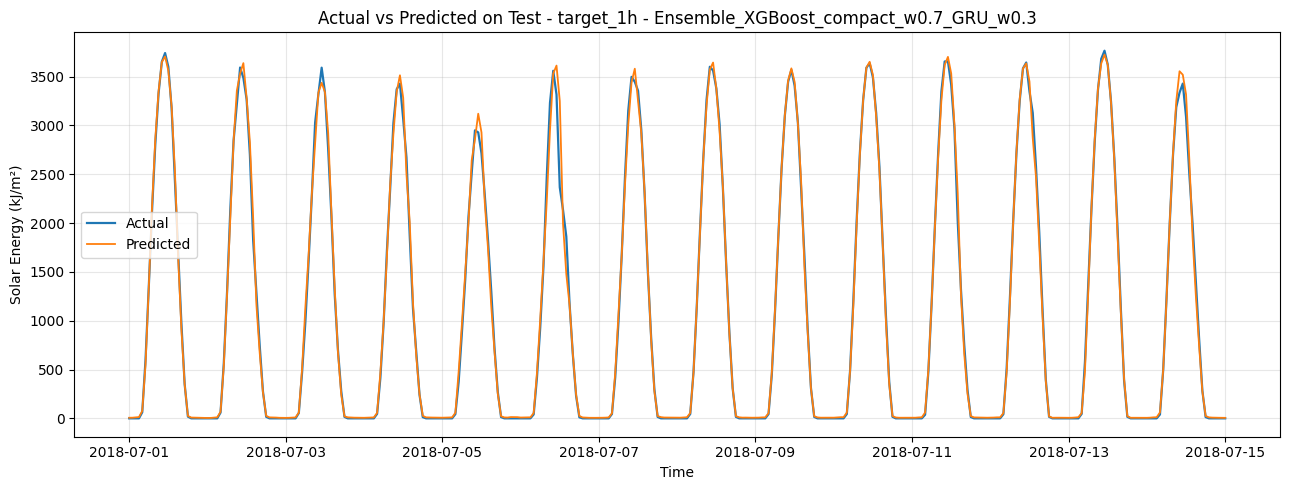

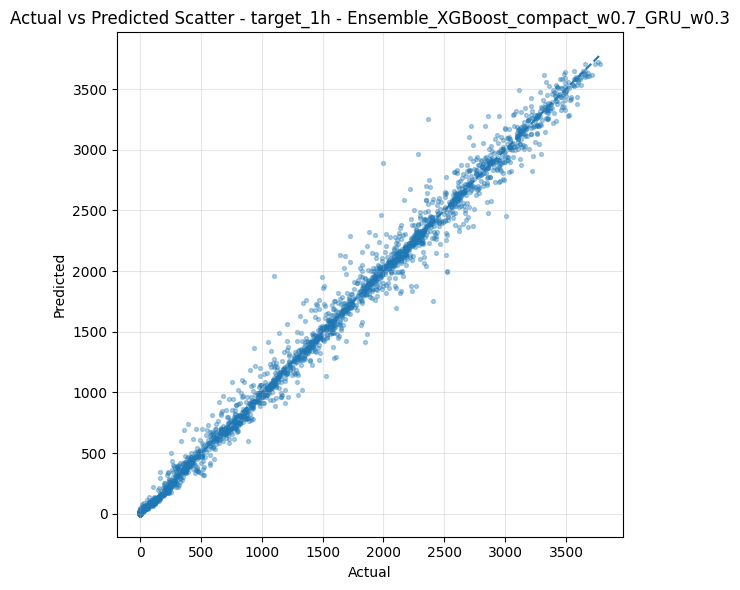

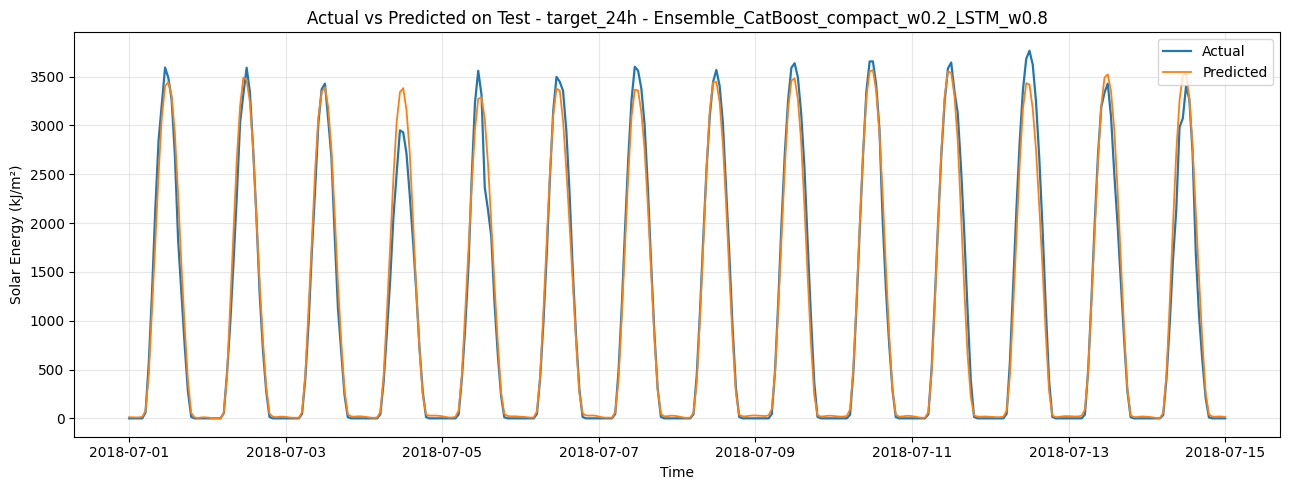

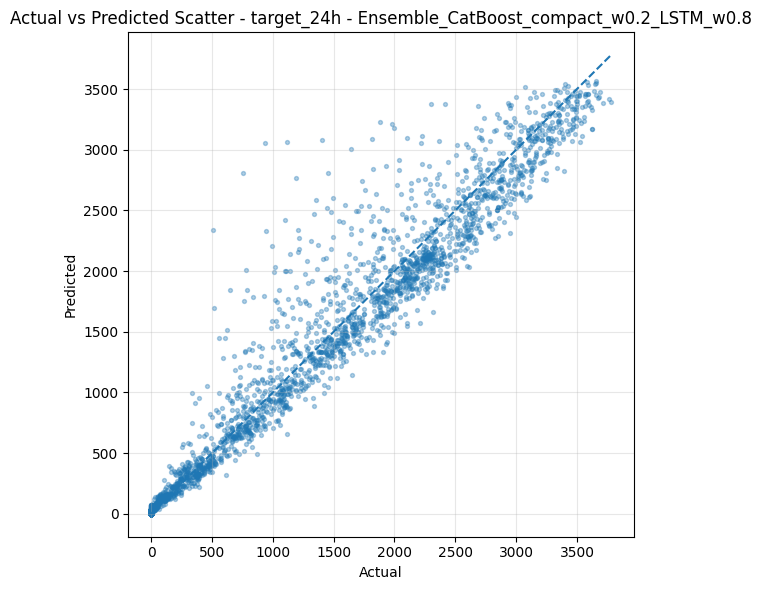

In [14]:
# =========================
# 12. Actual vs Predicted plots
# =========================

def get_prediction_for_row(target_col, model_name):
    if (target_col, model_name) in prediction_store:
        return prediction_store[(target_col, model_name)]
    if (target_col, model_name) in ensemble_predictions:
        return ensemble_predictions[(target_col, model_name)]
    if (target_col, model_name) in boosting_predictions:
        return boosting_predictions[(target_col, model_name)]
    return None

def align_prediction_object(pred_obj, split="test"):
    y = _to_1d(pred_obj[f"{split}_true"])
    pred = _to_1d(pred_obj[f"{split}_pred"])
    times = pd.DatetimeIndex(pred_obj[f"{split}_time"])
    n = min(len(y), len(pred), len(times))
    return y[-n:], pred[-n:], times[-n:]

for target_col in TARGETS_TO_RUN:
    best_row = final_summary[
        (final_summary["target"] == target_col) &
        (final_summary.get("status", "ok") == "ok")
    ].sort_values("val_daylight_RMSE").head(1)

    if best_row.empty:
        continue

    best_model_name = best_row.iloc[0]["model"]
    pred_obj = get_prediction_for_row(target_col, best_model_name)
    if pred_obj is None:
        print(f"No prediction object for {target_col} - {best_model_name}")
        continue

    y_true, y_pred, times = align_prediction_object(pred_obj, split="test")
    plot_mask = times <= times.min() + pd.Timedelta(days=14)

    plt.figure(figsize=(13, 5))
    plt.plot(times[plot_mask], y_true[plot_mask], label="Actual", linewidth=1.6)
    plt.plot(times[plot_mask], y_pred[plot_mask], label="Predicted", linewidth=1.3)
    plt.title(f"Actual vs Predicted on Test - {target_col} - {best_model_name}")
    plt.xlabel("Time")
    plt.ylabel("Solar Energy (kJ/m²)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"03_actual_vs_predicted_{target_col}.png", dpi=160)
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=8, alpha=0.35)
    max_v = max(float(np.max(y_true)), float(np.max(y_pred)))
    plt.plot([0, max_v], [0, max_v], linestyle="--")
    plt.title(f"Actual vs Predicted Scatter - {target_col} - {best_model_name}")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"03_scatter_{target_col}.png", dpi=160)
    plt.show()

## 13. Error analysis theo giờ và tháng

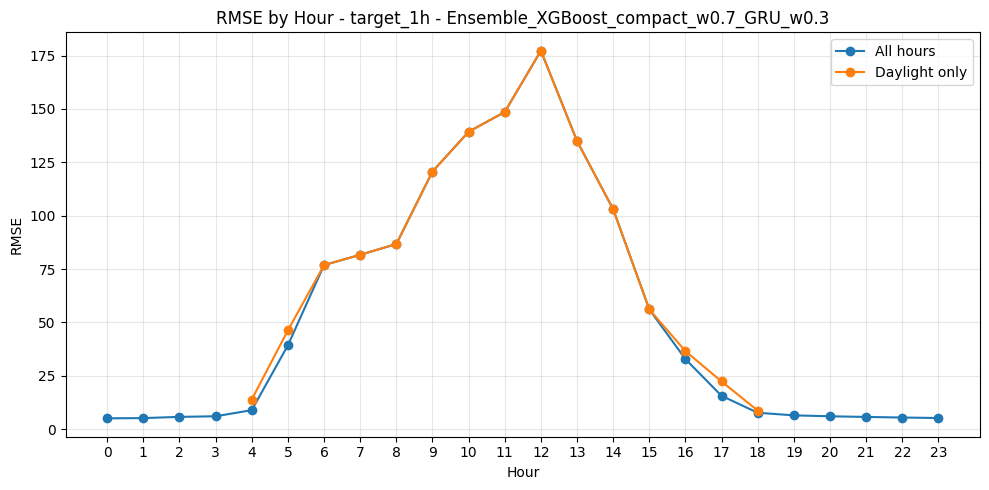

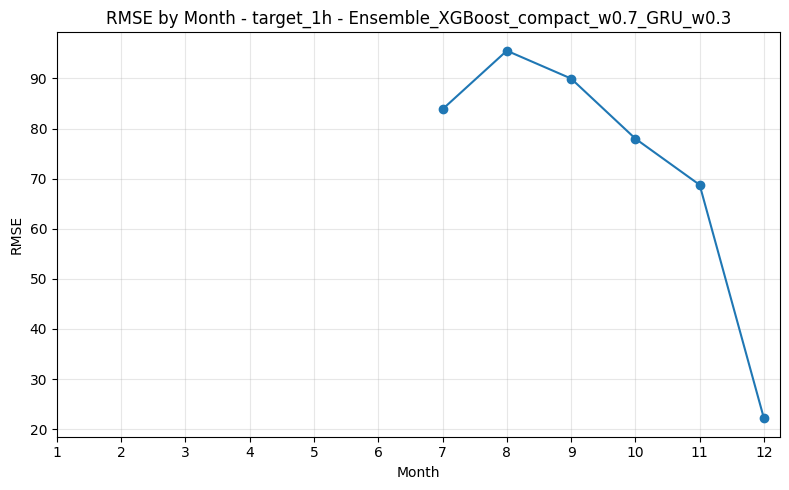

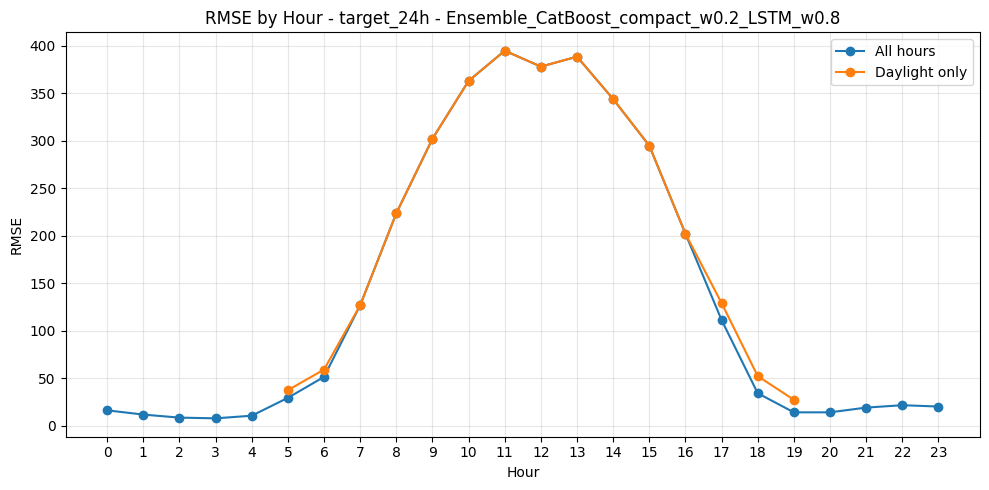

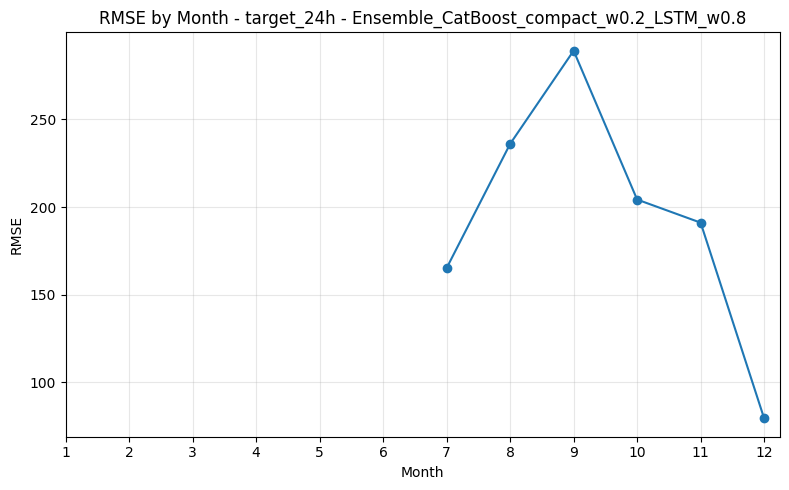

,group_value,MAE,RMSE,count,target,model,group
0,0,4.865415,5.066915,183,target_1h,Ensemble_XGBoost_compact_w0.7_GRU_w0.3,hour_all
1,1,4.915086,5.182448,183,target_1h,Ensemble_XGBoost_compact_w0.7_GRU_w0.3,hour_all
2,2,5.343261,5.753955,183,target_1h,Ensemble_XGBoost_compact_w0.7_GRU_w0.3,hour_all
3,3,5.390091,6.032668,183,target_1h,Ensemble_XGBoost_compact_w0.7_GRU_w0.3,hour_all
4,4,7.499632,8.906115,183,target_1h,Ensemble_XGBoost_compact_w0.7_GRU_w0.3,hour_all


In [15]:
# =========================
# 13. Error analysis
# =========================

error_analysis_rows = []

for target_col in TARGETS_TO_RUN:
    best_row = final_summary[
        (final_summary["target"] == target_col) &
        (final_summary.get("status", "ok") == "ok")
    ].sort_values("val_daylight_RMSE").head(1)

    if best_row.empty:
        continue

    best_model_name = best_row.iloc[0]["model"]
    pred_obj = get_prediction_for_row(target_col, best_model_name)
    if pred_obj is None:
        continue

    y_true, y_pred, times = align_prediction_object(pred_obj, split="test")
    err_df = pd.DataFrame({"time": times, "y_true": y_true, "y_pred": y_pred}).set_index("time")
    err_df["abs_error"] = np.abs(err_df["y_true"] - err_df["y_pred"])
    err_df["sq_error"] = (err_df["y_true"] - err_df["y_pred"]) ** 2
    err_df["hour"] = err_df.index.hour
    err_df["month"] = err_df.index.month
    err_df["is_daylight"] = err_df["y_true"] > DAYLIGHT_THRESHOLD

    by_hour = err_df.groupby("hour").agg(
        MAE=("abs_error", "mean"),
        RMSE=("sq_error", lambda x: float(np.sqrt(np.mean(x)))),
        count=("abs_error", "size"),
    ).reset_index()
    by_hour["target"], by_hour["model"], by_hour["group"] = target_col, best_model_name, "hour_all"
    by_hour = by_hour.rename(columns={"hour": "group_value"})

    by_hour_daylight = err_df[err_df["is_daylight"]].groupby("hour").agg(
        MAE=("abs_error", "mean"),
        RMSE=("sq_error", lambda x: float(np.sqrt(np.mean(x)))),
        count=("abs_error", "size"),
    ).reset_index()
    by_hour_daylight["target"], by_hour_daylight["model"], by_hour_daylight["group"] = target_col, best_model_name, "hour_daylight"
    by_hour_daylight = by_hour_daylight.rename(columns={"hour": "group_value"})

    by_month = err_df.groupby("month").agg(
        MAE=("abs_error", "mean"),
        RMSE=("sq_error", lambda x: float(np.sqrt(np.mean(x)))),
        count=("abs_error", "size"),
    ).reset_index()
    by_month["target"], by_month["model"], by_month["group"] = target_col, best_model_name, "month_all"
    by_month = by_month.rename(columns={"month": "group_value"})

    error_analysis_rows.extend([by_hour, by_hour_daylight, by_month])

    plt.figure(figsize=(10, 5))
    plt.plot(by_hour["group_value"], by_hour["RMSE"], marker="o", label="All hours")
    if not by_hour_daylight.empty:
        plt.plot(by_hour_daylight["group_value"], by_hour_daylight["RMSE"], marker="o", label="Daylight only")
    plt.title(f"RMSE by Hour - {target_col} - {best_model_name}")
    plt.xlabel("Hour")
    plt.ylabel("RMSE")
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"03_error_by_hour_{target_col}.png", dpi=160)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(by_month["group_value"], by_month["RMSE"], marker="o")
    plt.title(f"RMSE by Month - {target_col} - {best_model_name}")
    plt.xlabel("Month")
    plt.ylabel("RMSE")
    plt.xticks(range(1, 13))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"03_error_by_month_{target_col}.png", dpi=160)
    plt.show()

if error_analysis_rows:
    error_analysis_df = pd.concat(error_analysis_rows, ignore_index=True)
    error_analysis_df.to_csv(OUT_DIR / "03_error_analysis.csv", index=False)
    display(error_analysis_df.head())
else:
    print("No error analysis rows.")

## 14. Permutation importance cho best deep model

Permutation importance for target_1h - LSTM
Permutation importance for target_24h - LSTM


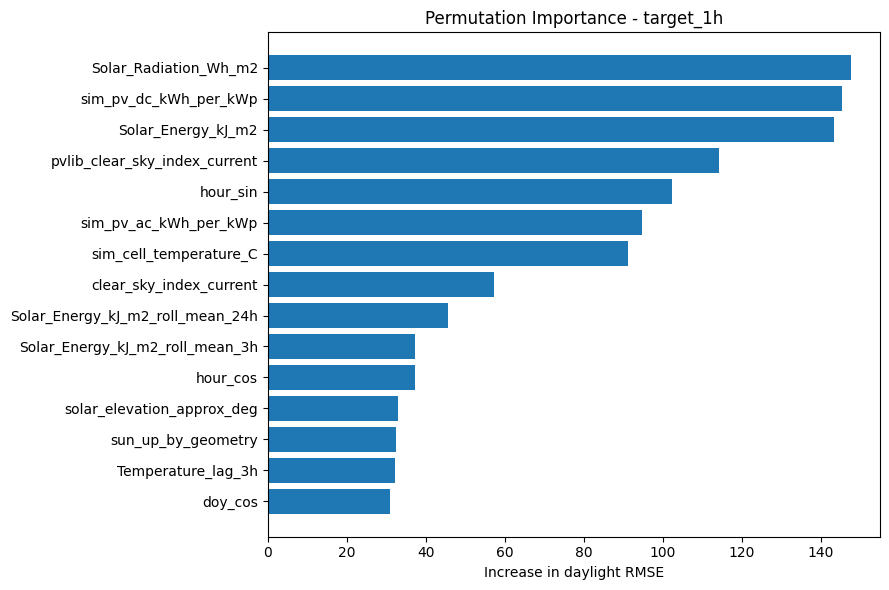

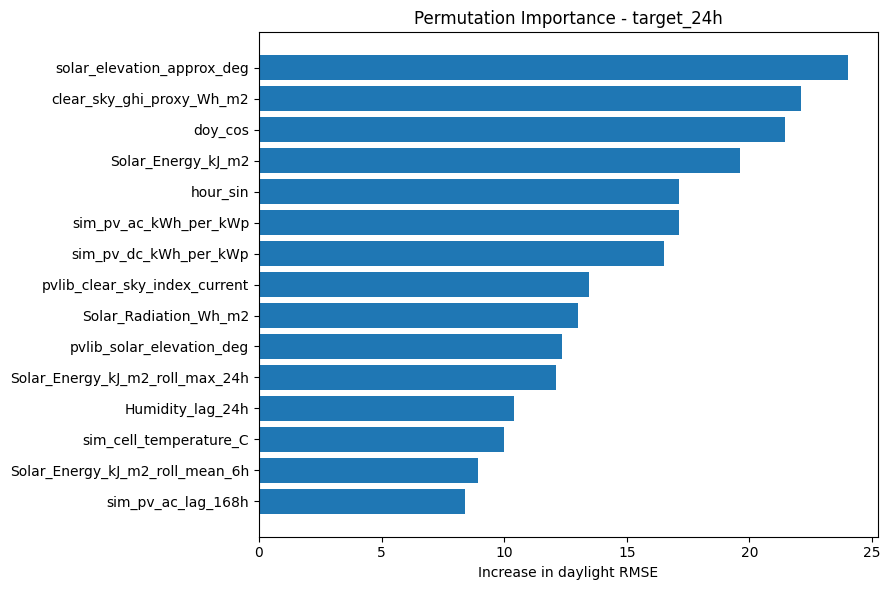

,target,model,feature,base_daylight_RMSE,permuted_daylight_RMSE,importance_rmse_increase
1,target_1h,LSTM,Solar_Radiation_Wh_m2,144.951298,292.554001,147.602703
23,target_1h,LSTM,sim_pv_dc_kWh_per_kWp,144.951298,290.433996,145.482698
0,target_1h,LSTM,Solar_Energy_kJ_m2,144.951298,288.338356,143.387058
21,target_1h,LSTM,pvlib_clear_sky_index_current,144.951298,259.222651,114.271353
7,target_1h,LSTM,hour_sin,144.951298,247.417355,102.466057
24,target_1h,LSTM,sim_pv_ac_kWh_per_kWp,144.951298,239.826378,94.875079
22,target_1h,LSTM,sim_cell_temperature_C,144.951298,236.109093,91.157795
17,target_1h,LSTM,clear_sky_index_current,144.951298,202.296329,57.345031
36,target_1h,LSTM,Solar_Energy_kJ_m2_roll_mean_24h,144.951298,190.713955,45.762656
34,target_1h,LSTM,Solar_Energy_kJ_m2_roll_mean_3h,144.951298,182.344636,37.393338


In [16]:
# =========================
# 14. Permutation importance for best deep model
# =========================

importance_rows = []

if RUN_PERMUTATION_IMPORTANCE:
    for target_col in TARGETS_TO_RUN:
        target_dl = dl_results_df[
            (dl_results_df["target"] == target_col) &
            (dl_results_df.get("status", "ok") == "ok")
        ].sort_values("val_daylight_RMSE")

        if target_dl.empty:
            continue

        best_deep_name = target_dl.iloc[0]["model"]
        ckpt_path = MODEL_DIR / f"03_{target_col}_{best_deep_name}.pt"
        if not ckpt_path.exists():
            print(f"Checkpoint not found, skip: {ckpt_path}")
            continue

        print(f"Permutation importance for {target_col} - {best_deep_name}")

        checkpoint = torch.load(ckpt_path, map_location=DEVICE)
        ckpt_features = checkpoint.get("seq_features", seq_features)
        ckpt_n_features = int(checkpoint.get("n_features", len(ckpt_features)))

        model = build_model(best_deep_name, seq_len=LOOKBACK, n_features=ckpt_n_features)
        model.load_state_dict(checkpoint["state_dict"])
        model.eval()

        scaled_data = sequence_store[target_col]["scaled_data"]
        X_test, y_test_scaled, y_test_orig, t_test, p_test = scaled_data["test"]
        y_scaler = scaler_store[target_col]["y_scaler"]

        if X_test.shape[-1] != ckpt_n_features:
            print(f"Feature mismatch for permutation importance: X_test={X_test.shape[-1]}, ckpt={ckpt_n_features}. Skip.")
            continue

        feature_names = ckpt_features if len(ckpt_features) == X_test.shape[-1] else [f"feature_{j}" for j in range(X_test.shape[-1])]

        rng = np.random.default_rng(SEED)
        n = min(PERMUTATION_SAMPLE_SIZE, len(X_test))
        idx = rng.choice(len(X_test), size=n, replace=False)
        X_sub = X_test[idx].copy()
        y_sub = y_test_orig[idx].copy()

        base_pred = predict_model(model, X_sub, y_scaler)
        base_rmse = evaluate_predictions(y_sub, base_pred)["daylight_RMSE"]

        for j, feat in enumerate(feature_names):
            X_perm = X_sub.copy()
            perm_idx = rng.permutation(n)
            X_perm[:, :, j] = X_perm[perm_idx, :, j]

            perm_pred = predict_model(model, X_perm, y_scaler)
            perm_rmse = evaluate_predictions(y_sub, perm_pred)["daylight_RMSE"]

            importance_rows.append({
                "target": target_col,
                "model": best_deep_name,
                "feature": feat,
                "base_daylight_RMSE": base_rmse,
                "permuted_daylight_RMSE": perm_rmse,
                "importance_rmse_increase": perm_rmse - base_rmse,
            })

importance_df = pd.DataFrame(importance_rows)

if not importance_df.empty:
    importance_df = importance_df.sort_values(["target", "importance_rmse_increase"], ascending=[True, False])
    importance_df.to_csv(OUT_DIR / "03_deep_feature_importance.csv", index=False)

    for target_col in TARGETS_TO_RUN:
        top = importance_df[importance_df["target"] == target_col].head(15)
        if top.empty:
            continue

        plt.figure(figsize=(9, 6))
        plt.barh(top["feature"][::-1], top["importance_rmse_increase"][::-1])
        plt.title(f"Permutation Importance - {target_col}")
        plt.xlabel("Increase in daylight RMSE")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"03_permutation_importance_{target_col}.png", dpi=160)
        plt.show()

    display(importance_df.head(20))
else:
    print("Permutation importance skipped or empty.")

## 15. Kết luận nhanh cho 03

Sau khi chạy xong notebook này, các file chính nằm trong:

- `outputs_03/03_results_deep_learning.csv`
- `outputs_03/03_results_ensemble.csv`
- `outputs_03/03_final_summary_for_report.csv`
- `outputs_03/03_training_history.csv`
- `outputs_03/03_deep_feature_importance.csv`
- `outputs_03/03_error_analysis.csv`

Nếu deep learning không vượt XGBoost/CatBoost thì vẫn là kết quả có giá trị: nó cho thấy với dữ liệu single-site NASA POWER và feature engineering tốt, tree boosting trên lag/rolling/cyclic/physical features là baseline rất mạnh.